In [359]:
import warnings

DEBUG = False
RANDOM_STATE = 2024
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster")

In [360]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import SelectFromModel
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [361]:
# UTILS

def plot_venn(sets, labels, title):
    plt.figure(figsize=(10, 7))
    if len(sets) == 2:
        venn2(sets, set_labels=labels)
    elif len(sets) == 3:
        venn3(sets, set_labels=labels)
    plt.title(title)
    plt.show()

def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred)


# Набор данных

In [362]:
file_path = "SMS.tsv"
data = pd.read_csv(file_path, sep='\t')

if DEBUG:
    data = data.sample(n=1000, random_state=RANDOM_STATE)

data.tail()

,class,text
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [363]:
class_distribution = data['class'].value_counts(normalize=True) * 100
class_distribution

class
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

In [364]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

def class_to_int(cls):
    return 1 if cls == 'spam' else 0

data['cleaned_text'] = data['text'].apply(clean_text)
data['class'] = data['class'].apply(class_to_int)

vectorizer = CountVectorizer(max_features=2000) if DEBUG else CountVectorizer()
X = vectorizer.fit_transform(data['cleaned_text']).toarray()
y = data['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=RANDOM_STATE)

print("Размерности данных:")
print(f"Обучающая выборка: {X_train.shape}")
print(f"Валидационная выборка: {X_val.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Размерности данных:
Обучающая выборка: (3342, 9544)
Валидационная выборка: (1115, 9544)
Тестовая выборка: (1115, 9544)


# Алгоритмы + Сравнение

## Встроенные методы

In [365]:
# Логистическая регрессия с L1-регуляризацией
model = LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Получаем важности признаков
coef = model.coef_[0]
non_zero_indices = np.where(coef != 0)[0]  # Индексы значимых признаков
top_30_indices = np.argsort(np.abs(coef[non_zero_indices]))[::-1][:30]  # Топ-30 признаков
top_30_features_my_embedded = set([vectorizer.get_feature_names_out()[i] for i in non_zero_indices[top_30_indices]])

print("Самостоятельная реализация (встроенный метод):")
print("Топ-30 признаков:", top_30_features_my_embedded)


Самостоятельная реализация (встроенный метод):
Топ-30 признаков: {'100', 'truly', 'orange', 'choose', 'games', 'text', '800', 'who', 'ringtone', 'real', 'service', 'urgent', 'sexy', 'call', 'lucy', 'statement', 'ltgt', 'pics', '500', 'sex', 'customer', 'reply', 'claim', 'prize', 'user', 'txt', 'stop', 'chat', '250', 'apply'}


In [366]:
# Создаем и обучаем модель
model = RandomForestClassifier(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Используем SelectFromModel для выбора значимых признаков
selector = SelectFromModel(model, prefit=True, threshold="mean")
X_train_embedded = selector.transform(X_train)
X_val_embedded = selector.transform(X_val)
X_test_embedded = selector.transform(X_test)

# Получение важностей признаков и индексов
importances = model.feature_importances_
sorted_indices = np.argsort(importances)[::-1]  # Индексы признаков по убыванию важности

# Выбираем топ-30 признаков по важности
top_30_features_lib_embedded = set([vectorizer.get_feature_names_out()[i] for i in sorted_indices[:30]])

print("Библиотечная реализация (встроенный метод):")
print("Топ-30 признаков:", top_30_features_lib_embedded)


Библиотечная реализация (встроенный метод):
Топ-30 признаков: {'18', 'code', 'per', 'to', 'text', 'service', 'urgent', 'free', 'call', 'win', 'from', 'nokia', 'awarded', '500', '150', 'cash', 'or', 'mobile', 'reply', 'claim', '16', 'prize', 'txt', 'stop', 'your', 'won', '150p', 'chat', 'customer', '1000'}


In [367]:
# Самостоятельная реализация
X_train_my_embedded = X_train[:, non_zero_indices]
X_val_my_embedded = X_val[:, non_zero_indices]
X_test_my_embedded = X_test[:, non_zero_indices]

# Библиотечная реализация
X_train_lib_embedded = X_train_embedded
X_val_lib_embedded = X_val_embedded
X_test_lib_embedded = X_test_embedded

# Вывод результатов
print(f"Размерности после самостоятельной реализации: {X_train_my_embedded.shape}")
print(f"Размерности после библиотечной реализации: {X_train_lib_embedded.shape}")


Размерности после самостоятельной реализации: (3342, 177)
Размерности после библиотечной реализации: (3342, 1289)


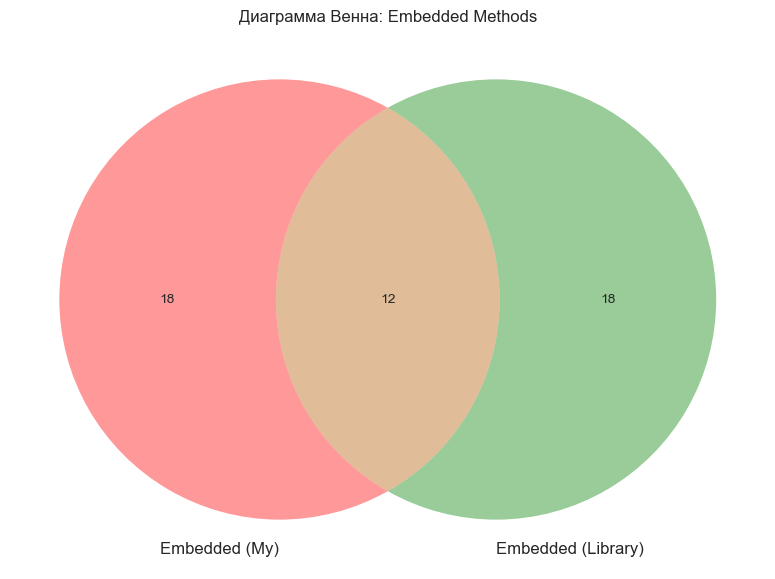

In [368]:
plot_venn((top_30_features_my_embedded, top_30_features_lib_embedded), labels=("Embedded (My)", "Embedded (Library)"), title="Диаграмма Венна: Embedded Methods")

## Методы-обертки

In [369]:
# Forward Selection
def forward_selection(X, y, X_val, y_val, model, num_features_to_select, importance_func=None):
    selected_features = []
    remaining_features = list(range(X.shape[1]))

    overall_best_score = 0
    while len(selected_features) < num_features_to_select:
        best_score = 0
        best_features = []  # Список признаков с одинаковым best_score
        for feature in remaining_features:
            current_features = selected_features + [feature]
            score = evaluate_model(model, X[:, current_features], y, X_val[:, current_features], y_val)

            if score > best_score:
                best_score = score
                best_features = [feature]
            elif score == best_score:
                best_features.append(feature)

        # Если есть признаки с одинаковым score, выбираем наиболее важный
        if importance_func is not None and best_features:
            # Обучаем модель на текущем наборе признаков
            model.fit(X[:, selected_features + best_features], y)
            importances = importance_func(model)
            importances = importances[len(selected_features):]
            best_feature = best_features[np.argsort(importances)[::-1][0]]
        else:
            if len(best_features) == 0:
                break
            best_feature = best_features[0]

        if best_score < overall_best_score:
            break
        overall_best_score = best_score
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)

        if DEBUG:
            print(f"Added feature {len(selected_features)}, score: {best_score:.4f}")

    return selected_features


model = LogisticRegression(solver='liblinear', random_state=RANDOM_STATE)

def importance_func_logreg(model):
    return np.abs(model.coef_[0])

selected_features_my_wrapper = forward_selection(X_train, y_train, X_val, y_val, model, 30, importance_func=importance_func_logreg)

top_30_features_my_wrapper = set([vectorizer.get_feature_names_out()[i] for i in selected_features_my_wrapper])

print("Самостоятельная реализация (обёртка):")
print("Топ-30 признаков:", top_30_features_my_wrapper)


Самостоятельная реализация (обёртка):
Топ-30 признаков: {'content', 'games', 'ringtone', 'service', 'ok', 'sexy', 'saucy', 'call', 'from', 'he', 'ltgt', 'ask', 'da', '500', 'ill', 'cash', 'local', 'im', 'that', '16', 'wait', 'txt', 'stop', 'me', '250', 'my', 'chat', 'sure', '18', 'apply'}


In [370]:
# Настройка модели
model = LogisticRegression(random_state=RANDOM_STATE)

# RFE с выбором 30 признаков
rfe = RFE(estimator=model, n_features_to_select=30)
rfe.fit(X_train, y_train)

# Получение индексов и названий признаков
selected_features_lib_wrapper = np.where(rfe.support_)[0]
top_30_features_lib_wrapper = set([vectorizer.get_feature_names_out()[i] for i in selected_features_lib_wrapper])

print("Библиотечная реализация (обёртка):")
print("Топ-30 признаков:", top_30_features_lib_wrapper)


Библиотечная реализация (обёртка):
Топ-30 признаков: {'100', 'wap', 'orange', 'content', '18', 'text', 'ringtone', 'urgent', 'free', 'sexy', 'call', 'win', 'statement', 'ltgt', '500', 'sex', 'network', 'mobile', 'later', 'reply', 'claim', 'user', 'txt', 'stop', 'won', 'me', 'chat', 'customer', 'play', 'apply'}


In [371]:
# Самостоятельная реализация
X_train_my_wrapper = X_train[:, selected_features_my_wrapper]
X_val_my_wrapper = X_val[:, selected_features_my_wrapper]
X_test_my_wrapper = X_test[:, selected_features_my_wrapper]

# Библиотечная реализация
X_train_lib_wrapper = X_train[:, selected_features_lib_wrapper]
X_val_lib_wrapper = X_val[:, selected_features_lib_wrapper]
X_test_lib_wrapper = X_test[:, selected_features_lib_wrapper]

# Вывод результатов
print(f"Размерности после самостоятельной реализации: {X_train_my_wrapper.shape}")
print(f"Размерности после библиотечной реализации: {X_train_lib_wrapper.shape}")


Размерности после самостоятельной реализации: (3342, 30)
Размерности после библиотечной реализации: (3342, 30)


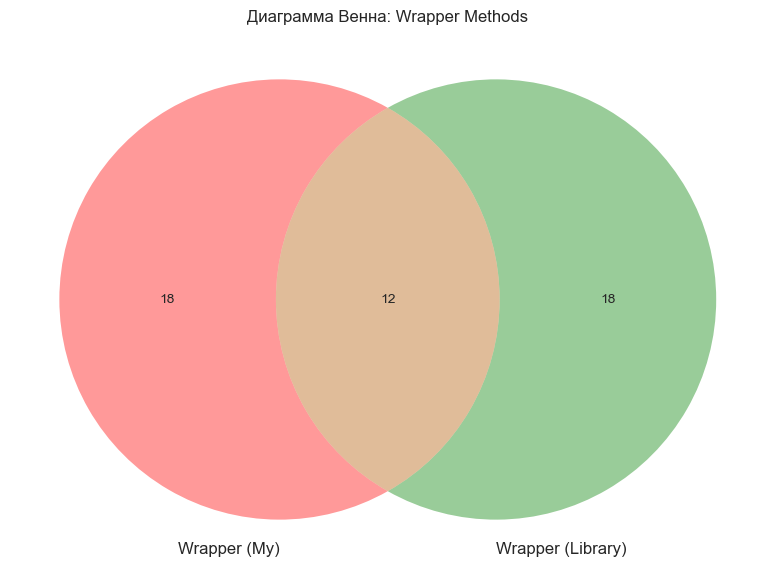

In [372]:
plot_venn((top_30_features_my_wrapper, top_30_features_lib_wrapper), labels=("Wrapper (My)", "Wrapper (Library)"), title="Диаграмма Венна: Wrapper Methods")

## Фильтрующие методы

In [373]:
from scipy.stats import entropy

# Функция для вычисления прироста информации
def compute_information_gain(X, y):
    total_entropy = entropy(np.bincount(y))
    ig_scores = []
    
    for feature in range(X.shape[1]):
        feature_values = X[:, feature]
        feature_values = (feature_values > 0).astype(int)
        unique_values, counts = np.unique(feature_values, return_counts=True)
        conditional_entropy = 0

        for value, count in zip(unique_values, counts):
            subset_y = y[feature_values == value]
            conditional_entropy += (count / len(y)) * entropy(np.bincount(subset_y))

        ig_score = total_entropy - conditional_entropy
        ig_scores.append(ig_score)

    return np.array(ig_scores)

# Функция для отбора топ-k признаков
def filter_by_information_gain(X, y, k):
    ig_scores = compute_information_gain(X, y)
    top_indices = np.argsort(ig_scores)[-k:]  # Индексы топ-k признаков
    return top_indices

# Отбор топ-30 признаков
selected_features_my_filter = filter_by_information_gain(X_train, y_train.values, 30)
top_30_features_my_filter = set([vectorizer.get_feature_names_out()[i] for i in selected_features_my_filter])

print("Самостоятельная реализация (фильтрующий метод на основе прироста информации):")
print("Топ-30 признаков:", top_30_features_my_filter)


Самостоятельная реализация (фильтрующий метод на основе прироста информации):
Топ-30 признаков: {'100', 'to', 'text', 'urgent', 'free', 'from', 'win', 'call', 'nokia', 'awarded', '150', '500', 'cash', 'or', 'mobile', '2000', 'reply', 'claim', '16', 'prize', 'tone', 'txt', 'our', 'stop', 'now', 'guaranteed', 'won', 'your', 'customer', '1000'}


In [374]:
from sklearn.feature_selection import SelectKBest, chi2

X_train_chi2 = (X_train > 0).astype(int)
y_train_chi2 = y_train.astype(int)

# SelectKBest с метрикой chi2
selector = SelectKBest(chi2, k=30)
selector.fit(X_train_chi2, y_train_chi2)

# Получение индексов и названий признаков
selected_features_lib_filter = selector.get_support(indices=True)
top_30_features_lib_filter = set([vectorizer.get_feature_names_out()[i] for i in selected_features_lib_filter])

print("Библиотечная реализация (фильтрующий метод):")
print("Топ-30 признаков:", top_30_features_lib_filter)


Библиотечная реализация (фильтрующий метод):
Топ-30 признаков: {'100', 'to', 'text', 'service', 'urgent', 'free', 'call', 'from', 'win', 'nokia', 'awarded', '150', '500', 'cash', 'or', 'mobile', '2000', 'reply', 'claim', '16', 'prize', 'tone', 'txt', 'stop', 'now', 'guaranteed', 'won', 'your', 'customer', '1000'}


In [375]:
# Самостоятельная реализация
X_train_my_filter = X_train[:, selected_features_my_filter]
X_val_my_filter = X_val[:, selected_features_my_filter]
X_test_my_filter = X_test[:, selected_features_my_filter]

# Библиотечная реализация
X_train_lib_filter = selector.transform(X_train)
X_val_lib_filter = selector.transform(X_val)
X_test_lib_filter = selector.transform(X_test)

# Вывод результатов
print(f"Размерности после самостоятельной реализации: {X_train_my_filter.shape}")
print(f"Размерности после библиотечной реализации: {X_train_lib_filter.shape}")


Размерности после самостоятельной реализации: (3342, 30)
Размерности после библиотечной реализации: (3342, 30)


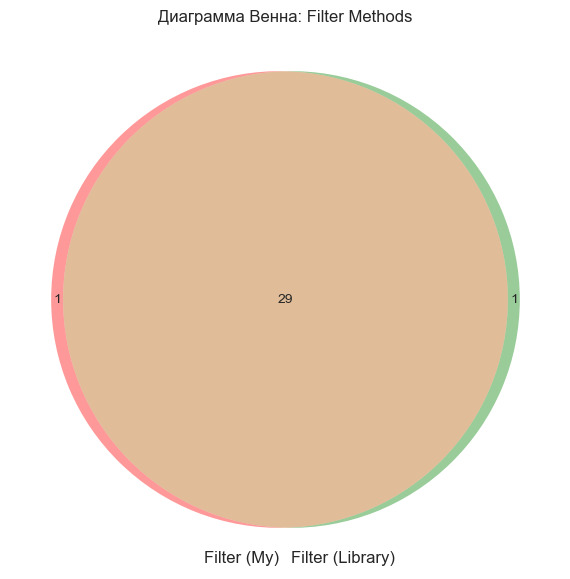

In [376]:
plot_venn((top_30_features_my_filter, top_30_features_lib_filter), labels=("Filter (My)", "Filter (Library)"), title="Диаграмма Венна: Filter Methods")

### Сравнение топ-30 признаков (слов)

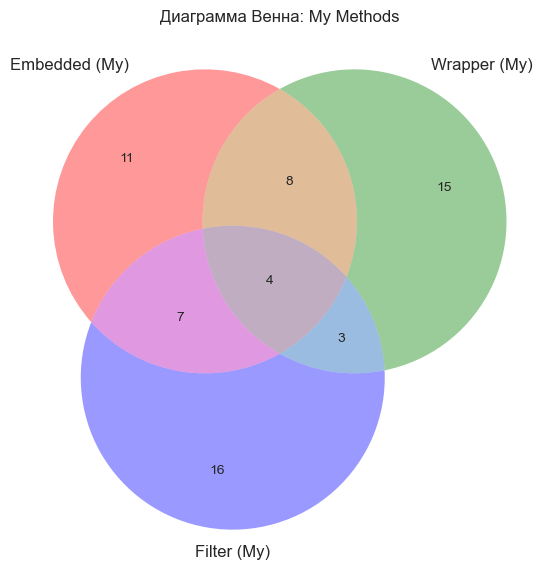

In [377]:
plot_venn(
    sets  = (top_30_features_my_embedded, top_30_features_my_wrapper, top_30_features_my_filter),
    labels= ("Embedded (My)", "Wrapper (My)", "Filter (My)"),
    title = "Диаграмма Венна: My Methods",
)

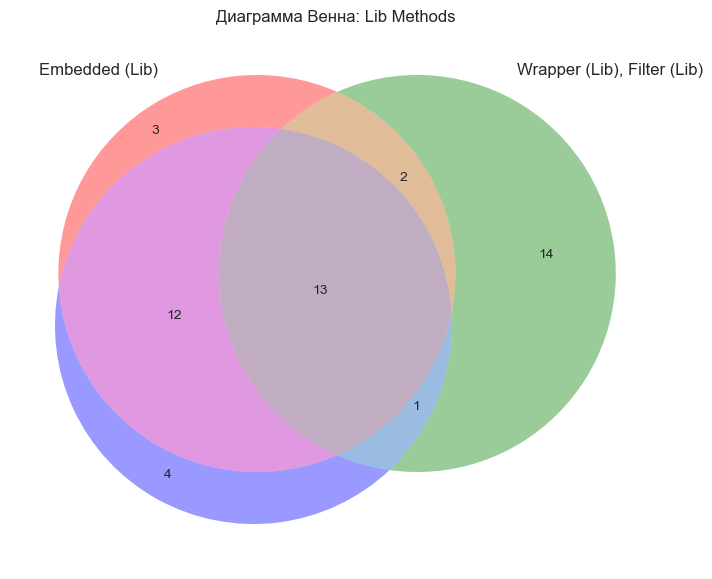

In [378]:
plot_venn(
    sets  = (top_30_features_lib_embedded, top_30_features_lib_wrapper, top_30_features_lib_filter),
    labels= ("Embedded (Lib)", "Wrapper (Lib), Filter (Lib)"),
    title = "Диаграмма Венна: Lib Methods",
)

### Сравнение классификаторов после различных методов выбора

In [379]:
# Все данные, которые будем анализировать
datasets = {
    "Original": (X_train, y_train, X_val, y_val),
    "Embedded (My)": (X_train_my_embedded, y_train, X_val_my_embedded, y_val),
    "Embedded (Lib)": (X_train_lib_embedded, y_train, X_val_lib_embedded, y_val),
    "Wrapper (My)": (X_train_my_wrapper, y_train, X_val_my_wrapper, y_val),
    "Wrapper (Lib)": (X_train_lib_wrapper, y_train, X_val_lib_wrapper, y_val),
    "Filter (My)": (X_train_my_filter, y_train, X_val_my_filter, y_val),
    "Filter (Lib)": (X_train_lib_filter, y_train, X_val_lib_filter, y_val),
}

# Классификаторы
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE)
}

# Словарь для хранения результатов в таблице
results_table = pd.DataFrame(columns=classifiers.keys(), index=datasets.keys())

# Цикл для заполнения таблицы
for method, (X_tr, y_tr, X_vl, y_vl) in datasets.items():
    for model_name, model in classifiers.items():
        score = evaluate_model(model, X_tr, y_tr, X_vl, y_vl)
        results_table.loc[method, model_name] = score

# Вывод таблицы
print("Результаты для различных методов выбора признаков:")
results_table


Результаты для различных методов выбора признаков:


,Logistic Regression,Random Forest,SVM
Original,0.917563,0.818898,0.860377
Embedded (My),0.885714,0.882353,0.884058
Embedded (Lib),0.913669,0.863636,0.886447
Wrapper (My),0.864111,0.834483,0.852113
Wrapper (Lib),0.78626,0.80916,0.798507
Filter (My),0.816176,0.813187,0.824373
Filter (Lib),0.817518,0.817844,0.826855


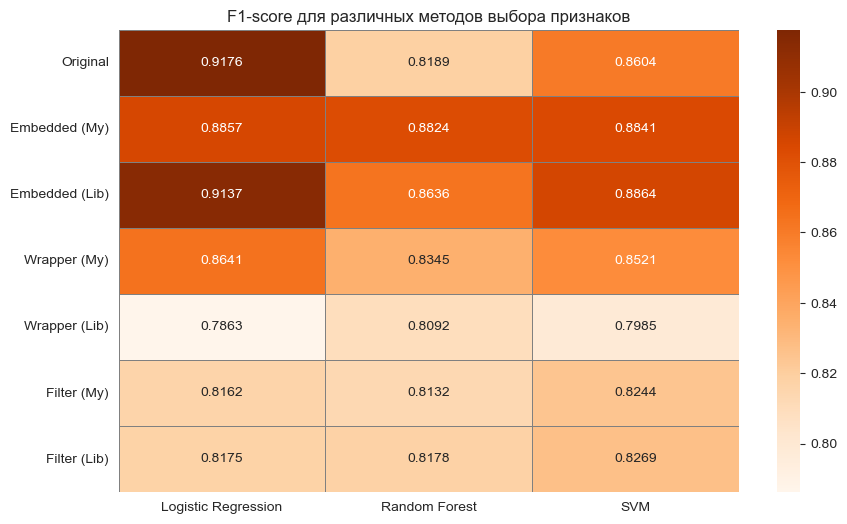

In [380]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    results_table.astype(float),
    annot=True,
    fmt=".4f", 
    linewidths=0.5,
    linecolor="gray",
    cmap="Oranges",
)
plt.title("F1-score для различных методов выбора признаков")
plt.show()


## Кластеризация

In [381]:
X_train_selected, y_train_selected, X_val_selected, y_val_selected = datasets["Embedded (My)"]

### Agglomerative Clustering

In [382]:
def evaluate_agglomerative(X, y_true, n_clusters=2):
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
    cluster_labels = agg_clustering.fit_predict(X)
    
    # Оценка метрик
    silhouette = silhouette_score(X, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    
    return cluster_labels, silhouette, ari

agg_labels_before, silhouette_agg_before, ari_agg_before = evaluate_agglomerative(X_train, y_train)
agg_labels_after, silhouette_agg_after, ari_agg_after = evaluate_agglomerative(X_train_selected, y_train_selected)

# Вывод результатов
print("AgglomerativeClustering до выбора признаков:")
print(f"  Silhouette Score: {silhouette_agg_before:.4f}")
print(f"  Adjusted Rand Index (ARI): {ari_agg_before:.4f}")
print()
print("AgglomerativeClustering после выбора признаков:")
print(f"  Silhouette Score: {silhouette_agg_after:.4f}")
print(f"  Adjusted Rand Index (ARI): {ari_agg_after:.4f}")

AgglomerativeClustering до выбора признаков:
  Silhouette Score: 0.3877
  Adjusted Rand Index (ARI): -0.0240

AgglomerativeClustering после выбора признаков:
  Silhouette Score: 0.3151
  Adjusted Rand Index (ARI): -0.0099


### KMeans

In [383]:
# Функция для выполнения кластеризации и оценки
def evaluate_kmeans(X, y_true, n_clusters=2):
    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE)
    cluster_labels = kmeans.fit_predict(X)
    
    # Оценка метрик
    silhouette = silhouette_score(X, cluster_labels)  # Внутренняя мера
    ari = adjusted_rand_score(y_true, cluster_labels)  # Внешняя мера
    
    return cluster_labels, silhouette, ari

kmeans_labels_before, kmeans_silhouette_before, kmeans_ari_before = evaluate_kmeans(X_train, y_train)
kmeans_labels_after, kmeans_silhouette_after, kmeans_ari_after = evaluate_kmeans(X_train_selected, y_train_selected)

# Вывод результатов
print("KMeans до выбора признаков:")
print(f"  Silhouette Score: {kmeans_silhouette_before:.4f}")
print(f"  Adjusted Rand Index (ARI): {kmeans_ari_before:.4f}")
print()
print("KMeans после выбора признаков:")
print(f"  Silhouette Score: {kmeans_silhouette_after:.4f}")
print(f"  Adjusted Rand Index (ARI): {kmeans_ari_after:.4f}")


KMeans до выбора признаков:
  Silhouette Score: 0.5708
  Adjusted Rand Index (ARI): -0.0005

KMeans после выбора признаков:
  Silhouette Score: 0.3803
  Adjusted Rand Index (ARI): 0.8006


### Gaussian Mixture

In [384]:
from sklearn.mixture import GaussianMixture

def evaluate_gmm(X, y_true, n_components=2, random_state=RANDOM_STATE):
    gmm = GaussianMixture(n_components=n_components, random_state=random_state)
    cluster_labels = gmm.fit_predict(X)

    # Вычисляем метрики
    silhouette = silhouette_score(X, cluster_labels) if len(set(cluster_labels)) > 1 else -1
    ari = adjusted_rand_score(y_true, cluster_labels)
    return cluster_labels, silhouette, ari

# Оценка GMM для данных до и после выбора признаков
gmm_labels_before, gmm_silhouette_before, gmm_ari_before = evaluate_gmm(X_train, y_train, n_components=2)
gmm_labels_after, gmm_silhouette_after, gmm_ari_after = evaluate_gmm(X_train_selected, y_train_selected, n_components=2)

# Вывод результатов
print("GMM до выбора признаков:")
print(f"  Silhouette Score: {gmm_silhouette_before:.4f}")
print(f"  Adjusted Rand Index (ARI): {gmm_ari_before:.4f}")
print()
print("GMM после выбора признаков:")
print(f"  Silhouette Score: {gmm_silhouette_after:.4f}")
print(f"  Adjusted Rand Index (ARI): {gmm_ari_after:.4f}")


GMM до выбора признаков:
  Silhouette Score: 0.1912
  Adjusted Rand Index (ARI): -0.0005

GMM после выбора признаков:
  Silhouette Score: 0.3253
  Adjusted Rand Index (ARI): 0.6434


In [392]:
def adjust_cluster_labels(cluster_labels):
    # Подсчет частоты каждой метки
    cluster_0_size = (cluster_labels == 0).sum()
    cluster_1_size = (cluster_labels == 1).sum()
    
    # Если кластер 1 содержит больше точек, меняем метки местами
    if cluster_1_size > cluster_0_size:
        cluster_labels = np.where(cluster_labels == 0, -1, cluster_labels)  # Временная метка
        cluster_labels = np.where(cluster_labels == 1, 0, cluster_labels)   # Назначение кластера 1 -> 0
        cluster_labels = np.where(cluster_labels == -1, 1, cluster_labels)  # Назначение временной метки -> 1
    
    return cluster_labels

labels_before = adjust_cluster_labels(kmeans_labels_before)
labels_after = adjust_cluster_labels(kmeans_labels_after)

In [393]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def plot_dim_reduction(X, labels, title, ax, real_classes=None):
    if real_classes is None:
        scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='bwr', alpha=0.8, edgecolor='k', s=25)
        legend_title = "Clusters"
    else:
        scatter = ax.scatter(X[:, 0], X[:, 1], c=real_classes, cmap='bwr', alpha=0.8, edgecolor='k', s=25)
        legend_title = "Classes"
    
    ax.legend(*scatter.legend_elements(), title=legend_title)
    ax.set_title(title, fontsize=10)
    ax.grid(True)

## PCA 2D

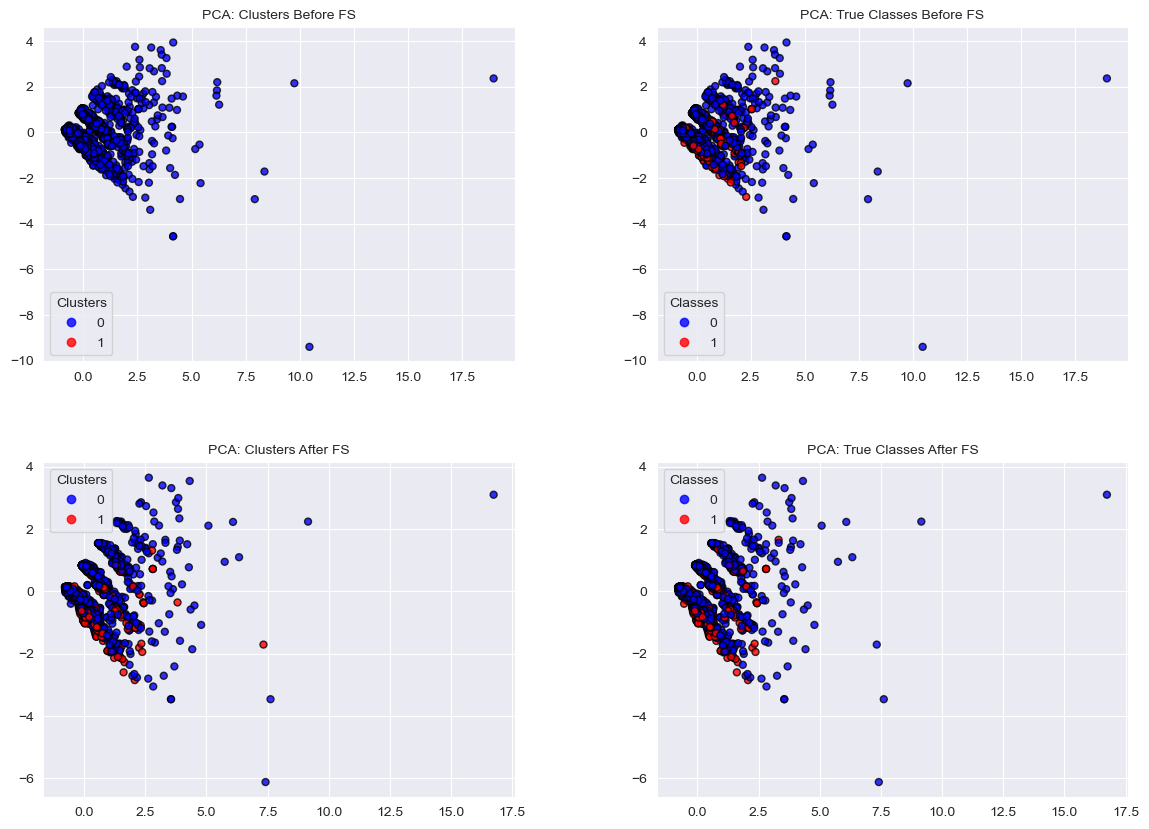

In [394]:
# Применение PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca_before = pca.fit_transform(X_train)
X_train_pca_after = pca.fit_transform(X_train_selected)

# Визуализация PCA до и после выбора признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'hspace': 0.3, 'wspace': 0.3})

plot_dim_reduction(X_train_pca_before, labels_before, "PCA: Clusters Before FS", axes[0, 0])
plot_dim_reduction(X_train_pca_before, y_train, "PCA: True Classes Before FS", axes[0, 1], real_classes=y_train)
plot_dim_reduction(X_train_pca_after, labels_after, "PCA: Clusters After FS", axes[1, 0])
plot_dim_reduction(X_train_pca_after, y_train_selected, "PCA: True Classes After FS", axes[1, 1], real_classes=y_train_selected)

plt.show()

## t-SNE 2D

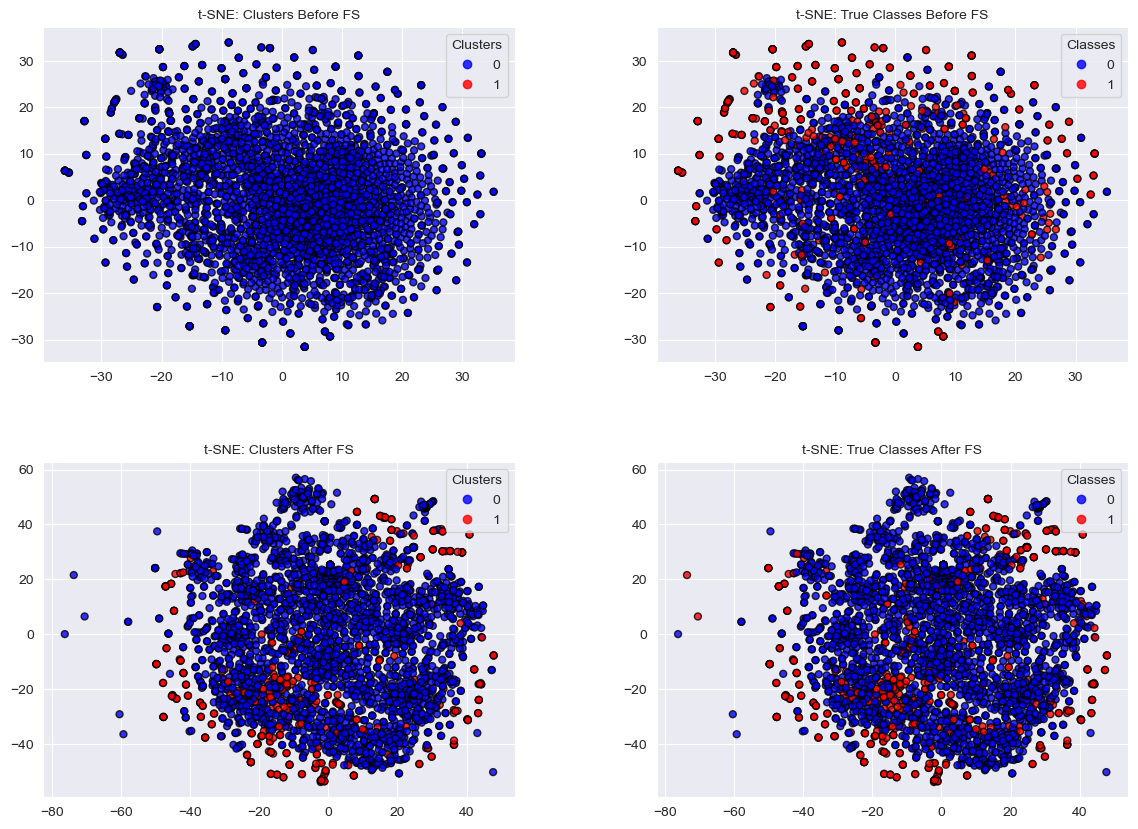

In [395]:
# Применение t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_train_tsne_before = tsne.fit_transform(X_train)
X_train_tsne_after = tsne.fit_transform(X_train_selected)

# Визуализация t-SNE до и после выбора признаков
fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'hspace': 0.3, 'wspace': 0.3})

plot_dim_reduction(X_train_tsne_before, labels_before, "t-SNE: Clusters Before FS", axes[0, 0])
plot_dim_reduction(X_train_tsne_before, y_train, "t-SNE: True Classes Before FS", axes[0, 1], real_classes=y_train)
plot_dim_reduction(X_train_tsne_after, labels_after, "t-SNE: Clusters After FS", axes[1, 0])
plot_dim_reduction(X_train_tsne_after, y_train_selected, "t-SNE: True Classes After FS", axes[1, 1], real_classes=y_train_selected)

plt.show()

In [396]:
# Функция для отрисовки 3D-графиков
def plot_3d_data(X, labels, title, ax, true_classes=None):
    if true_classes is not None:
        # Истинные классы
        scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=true_classes, cmap="bwr", s=70, alpha=0.6, edgecolors='k')
        legend_title = "True Classes"
    else:
        # Метки кластеров
        scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap="bwr", s=70, alpha=0.6, edgecolors='k')
        legend_title = "Clusters"

    ax.legend(*scatter.legend_elements(), title=legend_title, loc="best", fontsize=8)
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.5)

## PCA 3D

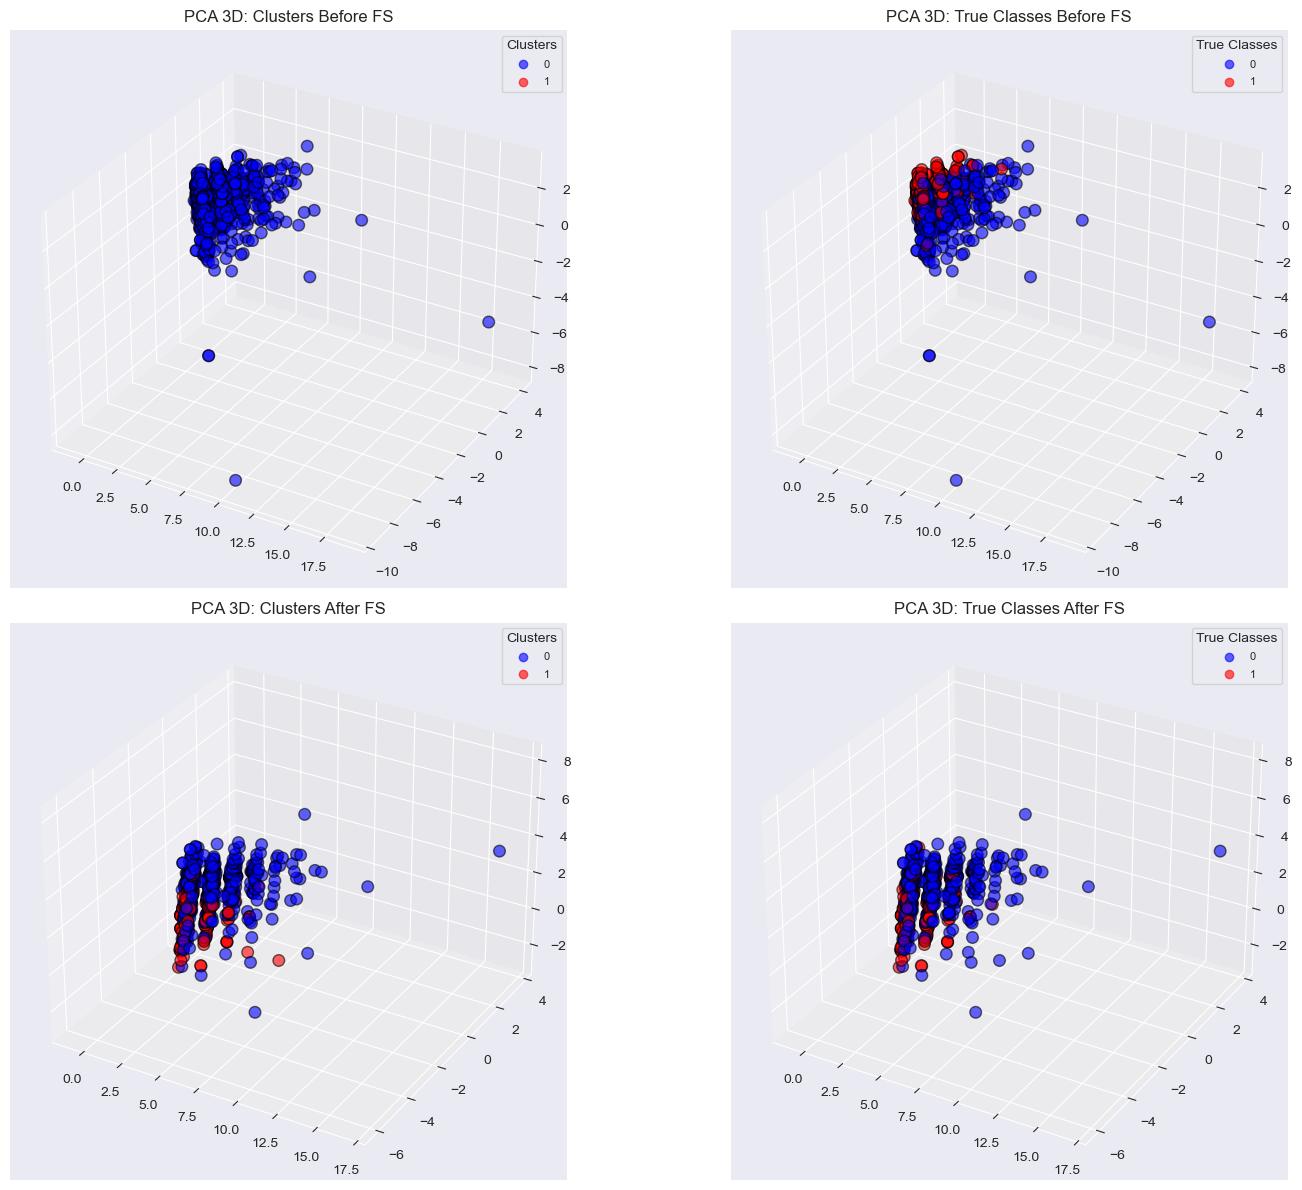

In [397]:
# Преобразование данных в 3D-пространство
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_train_pca_3d_before = pca_3d.fit_transform(X_train)
X_train_pca_3d_after = pca_3d.fit_transform(X_train_selected)

# Визуализация для PCA
fig_pca = plt.figure(figsize=(16, 12))

ax1 = fig_pca.add_subplot(221, projection='3d')
plot_3d_data(X_train_pca_3d_before, labels_before, "PCA 3D: Clusters Before FS", ax1)

ax2 = fig_pca.add_subplot(222, projection='3d')
plot_3d_data(X_train_pca_3d_before, y_train, "PCA 3D: True Classes Before FS", ax2, true_classes=y_train)

ax3 = fig_pca.add_subplot(223, projection='3d')
plot_3d_data(X_train_pca_3d_after, labels_after, "PCA 3D: Clusters After FS", ax3)

ax4 = fig_pca.add_subplot(224, projection='3d')
plot_3d_data(X_train_pca_3d_after, y_train_selected, "PCA 3D: True Classes After FS", ax4, true_classes=y_train_selected)

plt.tight_layout()
plt.show()


## t-SNE 3D

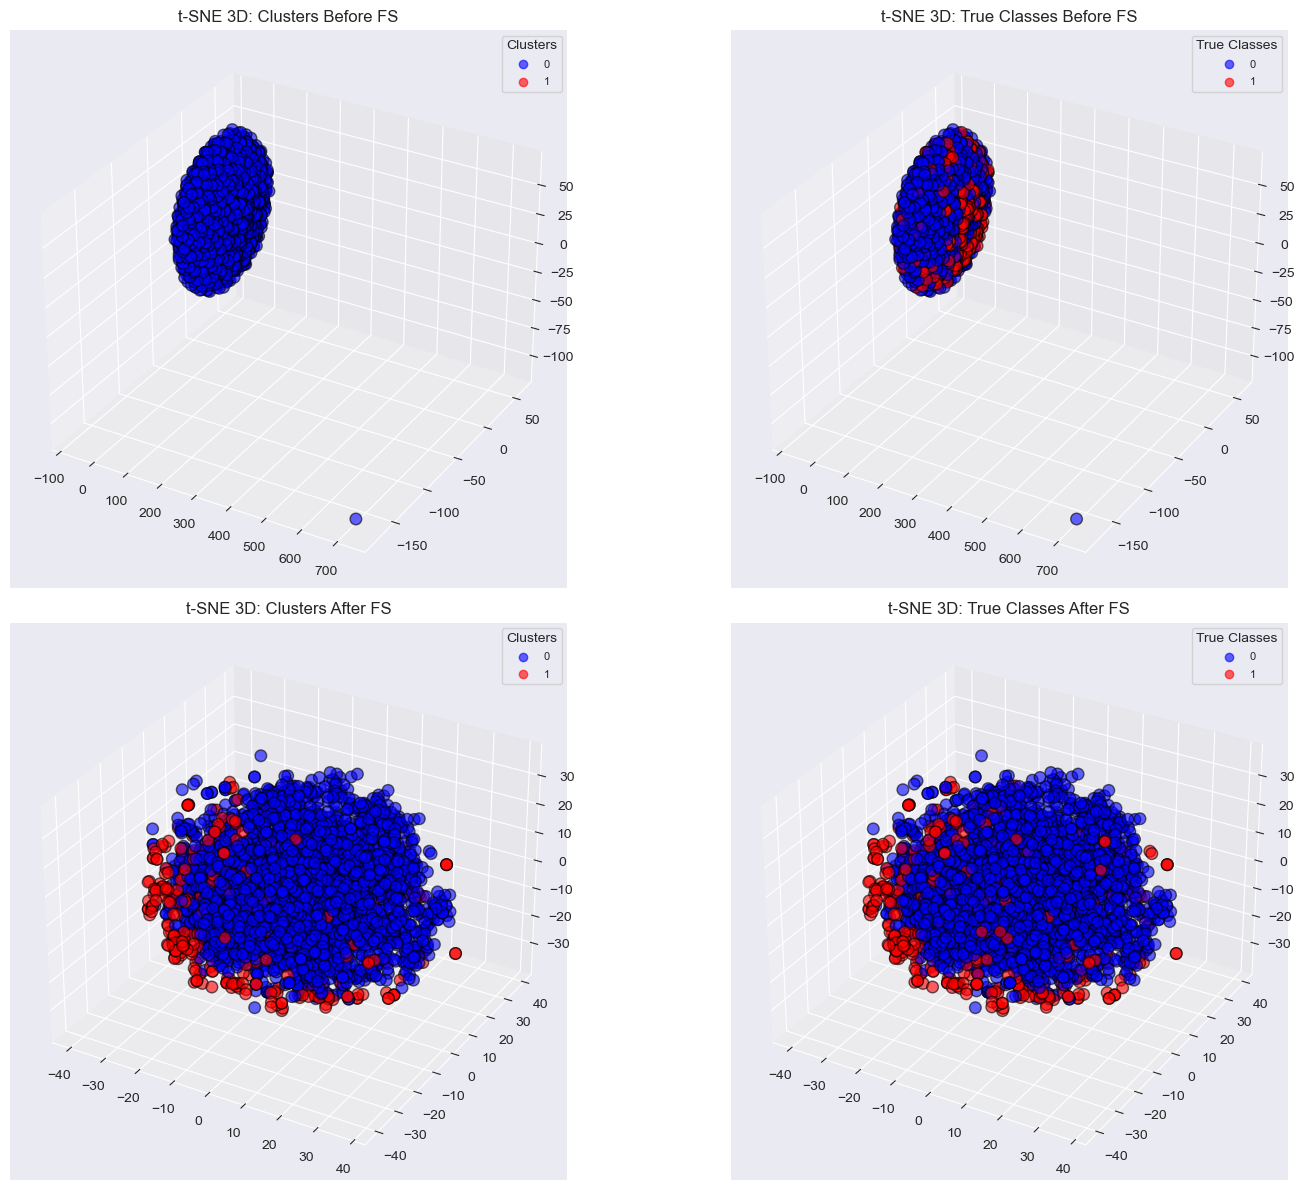

In [398]:
tsne_3d = TSNE(n_components=3, random_state=RANDOM_STATE)
X_train_tsne_3d_before = tsne_3d.fit_transform(X_train)
X_train_tsne_3d_after = tsne_3d.fit_transform(X_train_selected)

# Визуализация для t-SNE
fig_tsne = plt.figure(figsize=(16, 12))

ax5 = fig_tsne.add_subplot(221, projection='3d')
plot_3d_data(X_train_tsne_3d_before, labels_before, "t-SNE 3D: Clusters Before FS", ax5)

ax6 = fig_tsne.add_subplot(222, projection='3d')
plot_3d_data(X_train_tsne_3d_before, y_train, "t-SNE 3D: True Classes Before FS", ax6, true_classes=y_train)

ax7 = fig_tsne.add_subplot(223, projection='3d')
plot_3d_data(X_train_tsne_3d_after, labels_after, "t-SNE 3D: Clusters After FS", ax7)

ax8 = fig_tsne.add_subplot(224, projection='3d')
plot_3d_data(X_train_tsne_3d_after, y_train_selected, "t-SNE 3D: True Classes After FS", ax8, true_classes=y_train_selected)

plt.tight_layout()
plt.show()